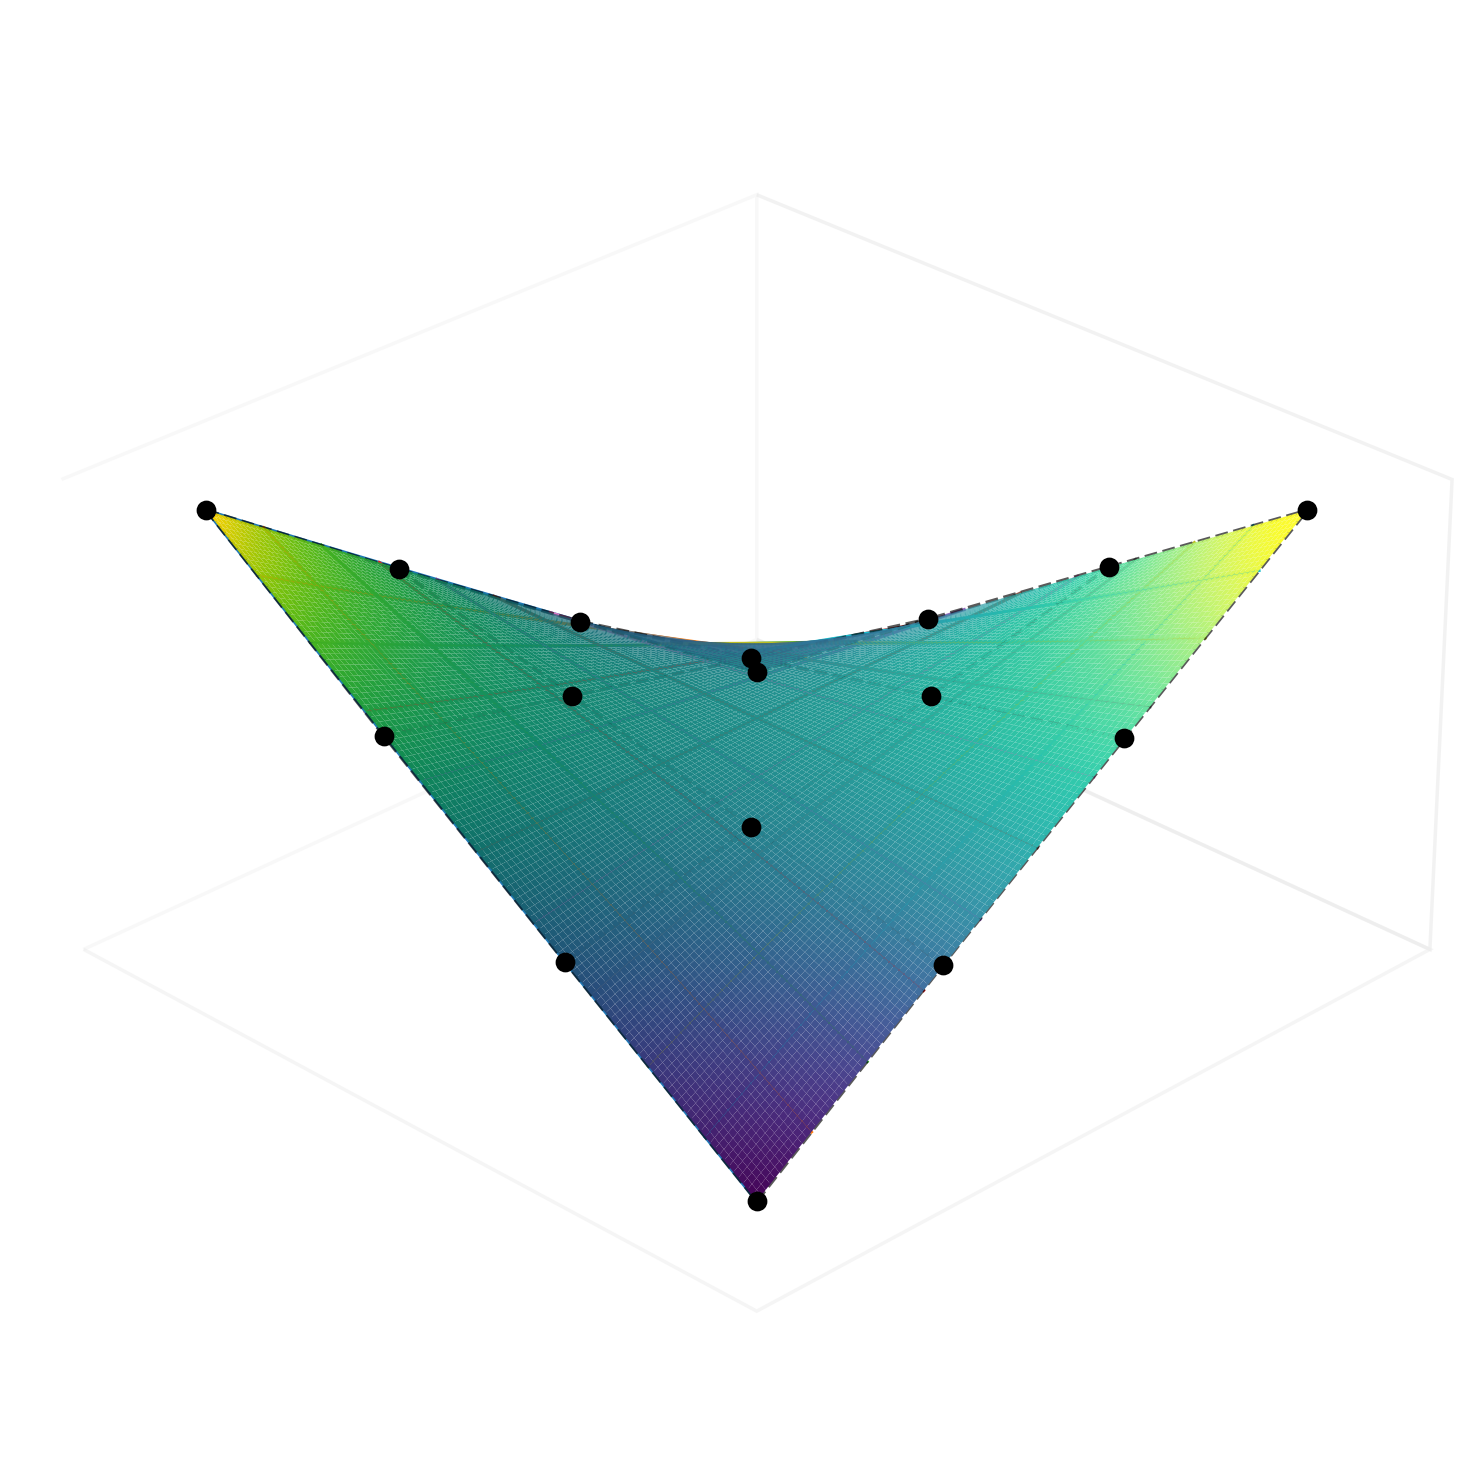

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def bernstein_basis(n: int, u: np.ndarray) -> np.ndarray:
    """
    Return all Bernstein basis functions of degree n evaluated at u.
    Shape: (n+1, len(u))
    """
    B = np.zeros((n + 1, len(u)))
    for i in range(n + 1):
        B[i, :] = comb(n, i, exact=True) * (u ** i) * ((1.0 - u) ** (n - i))
    return B


def eval_rational_bezier_surface(control_points, weights, nu=60, nv=60):
    """
    Evaluate a tensor-product rational Bezier surface.

    Parameters
    ----------
    control_points : ndarray, shape (p+1, q+1, 3)
        3D control points.
    weights : ndarray, shape (p+1, q+1)
        Rational weights.
    nu, nv : int
        Number of points in u and v directions.

    Returns
    -------
    X, Y, Z : ndarray, shape (nu, nv)
        Evaluated surface coordinates.
    """
    p = control_points.shape[0] - 1
    q = control_points.shape[1] - 1

    u = np.linspace(0.0, 1.0, nu)
    v = np.linspace(0.0, 1.0, nv)

    Bu = bernstein_basis(p, u)   # (p+1, nu)
    Bv = bernstein_basis(q, v)   # (q+1, nv)

    X = np.zeros((nu, nv))
    Y = np.zeros((nu, nv))
    Z = np.zeros((nu, nv))
    W = np.zeros((nu, nv))

    for i in range(p + 1):
        for j in range(q + 1):
            Nij = np.outer(Bu[i], Bv[j]) * weights[i, j]
            X += Nij * control_points[i, j, 0]
            Y += Nij * control_points[i, j, 1]
            Z += Nij * control_points[i, j, 2]
            W += Nij

    X /= W
    Y /= W
    Z /= W

    return X, Y, Z


def set_axes_equal_3d(ax):
    """
    Make axes of 3D plot have equal scale.
    """
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])


# def plot_rational_bezier_surface(control_points, weights, nu=80, nv=80,
#                                  show_control_net=True, show_isolines=True,
#                                  elev=28, azim=-45, savefig=None):
#     X, Y, Z = eval_rational_bezier_surface(control_points, weights, nu, nv)

#     fig = plt.figure(figsize=(8, 6), dpi=200)
#     ax = fig.add_subplot(111, projection='3d')

#     # Smooth surface
#     ax.plot_surface(
#         X, Y, Z,
#         rstride=1, cstride=1,
#         linewidth=0,
#         antialiased=True,
#         alpha=0.95
#     )

#     # Parameter-space isolines
#     if show_isolines:
#         iso_step = max(1, nu // 8)
#         for i in range(0, nu, iso_step):
#             ax.plot(X[i, :], Y[i, :], Z[i, :], lw=0.8)
#         iso_step = max(1, nv // 8)
#         for j in range(0, nv, iso_step):
#             ax.plot(X[:, j], Y[:, j], Z[:, j], lw=0.8)

#     # Control net
#     if show_control_net:
#         cp = control_points
#         m, n, _ = cp.shape

#         for i in range(m):
#             ax.plot(cp[i, :, 0], cp[i, :, 1], cp[i, :, 2], 'k--', lw=1.0, alpha=0.8)
#         for j in range(n):
#             ax.plot(cp[:, j, 0], cp[:, j, 1], cp[:, j, 2], 'k--', lw=1.0, alpha=0.8)

#         ax.scatter(cp[:, :, 0], cp[:, :, 1], cp[:, :, 2], s=20, c='k', depthshade=False)

#     ax.view_init(elev=elev, azim=azim)
#     set_axes_equal_3d(ax)

#     # Clean thesis-style look
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.set_zticks([])
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.set_zlabel("")
#     ax.set_box_aspect([1, 1, 0.55])

#     # Turn panes/grid mostly off
#     ax.grid(False)
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.line.set_linewidth(0.0)
#     ax.yaxis.line.set_linewidth(0.0)
#     ax.zaxis.line.set_linewidth(0.0)

#     plt.tight_layout()

#     if savefig is not None:
#         plt.savefig(savefig, bbox_inches="tight", pad_inches=0.02)

#     plt.show()

def plot_rational_bezier_surface(control_points, weights, nu=80, nv=80,
                                 show_control_net=True, show_isolines=True,
                                 elev=28, azim=-45, savefig=None):
    X, Y, Z = eval_rational_bezier_surface(control_points, weights, nu, nv)

    fig = plt.figure(figsize=(8, 6), dpi=250)
    ax = fig.add_subplot(111, projection='3d')

    # # Smooth surface
    # ax.plot_surface(
    #     X, Y, Z,
    #     rstride=1, cstride=1,
    #     linewidth=0,
    #     antialiased=True,
    #     alpha=0.92
    # )

    from matplotlib import cm
    from matplotlib.colors import LightSource

    # --- create lighting/shading ---
    ls = LightSource(azdeg=315, altdeg=45)

    # normalize Z for coloring
    Z_norm = (Z - Z.min()) / (Z.max() - Z.min())

    # pick a nice colormap (thesis-friendly)
    cmap = cm.viridis  # good default
    # alternatives:
    # cmap = cm.coolwarm
    # cmap = cm.cividis
    # cmap = cm.plasma

    # shaded colors
    rgb = ls.shade(Z_norm, cmap=cmap, vert_exag=0.7, blend_mode='soft')

    # plot surface with shading
    ax.plot_surface(
        X, Y, Z,
        facecolors=rgb,
        rstride=1, cstride=1,
        linewidth=0,
        antialiased=True,
        shade=False  # IMPORTANT: we already shaded manually
    )

    # Parameter-space isolines
    if show_isolines:
        iso_step_u = max(1, nu // 10)
        iso_step_v = max(1, nv // 10)
        for i in range(0, nu, iso_step_u):
            ax.plot(X[i, :], Y[i, :], Z[i, :], lw=0.9)
        for j in range(0, nv, iso_step_v):
            ax.plot(X[:, j], Y[:, j], Z[:, j], lw=0.9)

    # Control net
    if show_control_net:
        cp = control_points
        m, n, _ = cp.shape

        for i in range(m):
            ax.plot(cp[i, :, 0], cp[i, :, 1], cp[i, :, 2], 'k--', lw=1.0, alpha=0.65)
        for j in range(n):
            ax.plot(cp[:, j, 0], cp[:, j, 1], cp[:, j, 2], 'k--', lw=1.0, alpha=0.65)

        ax.scatter(cp[:, :, 0], cp[:, :, 1], cp[:, :, 2], s=22, c='k', depthshade=False)

    ax.view_init(elev=elev, azim=azim)
    set_axes_equal_3d(ax)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_zlabel("")
    ax.set_box_aspect([1, 1, 0.55])

    ax.grid(False)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.line.set_linewidth(0.0)
    ax.yaxis.line.set_linewidth(0.0)
    ax.zaxis.line.set_linewidth(0.0)

    plt.tight_layout()

    if savefig is not None:
        plt.savefig(savefig, bbox_inches="tight", pad_inches=0.02)

    plt.show()


# Example: curved rational Bezier patch for a "CAD/IGA-looking" intro figure
# control_points = np.array([
#     [[0.0, 0.0, 0.00], [0.0, 0.5, 0.20], [0.0, 1.0, 0.00]],
#     [[0.5, 0.0, 0.35], [0.5, 0.5, 0.60], [0.5, 1.0, 0.35]],
#     [[1.0, 0.0, 0.00], [1.0, 0.5, 0.20], [1.0, 1.0, 0.00]],
# ])

# weights = np.array([
#     [1.0, 0.7, 1.0],
#     [0.8, 1.4, 0.8],
#     [1.0, 0.7, 1.0],
# ])

# plot_rational_bezier_surface(
#     control_points,
#     weights,
#     nu=100,
#     nv=100,
#     show_control_net=True,
#     show_isolines=True,
#     elev=28,
#     azim=-45,
#     savefig="iga_surface_intro.png"
# )

# # Hyperbolic / saddle-like rational Bezier patch
control_points = np.array([
    [[0.0, 0.0,  0.55], [0.0, 0.33,  0.18], [0.0, 0.66, -0.18], [0.0, 1.0, -0.55]],
    [[0.33, 0.0, 0.18], [0.33, 0.33, 0.06], [0.33, 0.66, -0.06], [0.33, 1.0, -0.18]],
    [[0.66, 0.0,-0.18], [0.66, 0.33,-0.06], [0.66, 0.66,  0.06], [0.66, 1.0,  0.18]],
    [[1.0, 0.0, -0.55], [1.0, 0.33, -0.18], [1.0, 0.66,  0.18], [1.0, 1.0,  0.55]],
])

weights = np.array([
    [1.0, 0.95, 0.95, 1.0],
    [0.95, 1.05, 1.05, 0.95],
    [0.95, 1.05, 1.05, 0.95],
    [1.0, 0.95, 0.95, 1.0],
])

plot_rational_bezier_surface(
    control_points,
    weights,
    nu=120,
    nv=120,
    show_control_net=True,
    show_isolines=True,
    elev=28,
    azim=-45,
    savefig="iga_surface_hyperbolic.png"
)


# Bicubic Bezier patch with inflection in BOTH parametric directions
# z(u,v) behaves like (u-0.5)^3 + (v-0.5)^3, so each u-curve and v-curve
# has an S-shape / inflection.

# xg = np.array([0.0, 1.0/3.0, 2.0/3.0, 1.0])
# yg = np.array([0.0, 1.0/3.0, 2.0/3.0, 1.0])

# # Bernstein control coefficients for (t - 0.5)^3 in degree-3 Bezier form
# c = np.array([-1.0, 1.0, -1.0, 1.0]) / 8.0

# ax = 1.0   # strength of inflection in u-direction
# ay = 3.0   # strength of inflection in v-direction
# twist = 0.3  # optional extra twist so it looks less separable / boring

# control_points = np.zeros((4, 4, 3))

# for i in range(4):
#     for j in range(4):
#         x = xg[i]
#         y = yg[j]

#         # exact cubic-inflection behavior in both directions
#         z = ax * c[i] + ay * c[j]

#         # optional mixed term to make the shape more visually interesting
#         z += twist * (x - 0.5) * (y - 0.5)

#         control_points[i, j] = [x, y, z]

# weights = np.ones((4, 4))

# plot_rational_bezier_surface(
#     control_points,
#     weights,
#     nu=140,
#     nv=140,
#     show_control_net=True,
#     show_isolines=True,
#     elev=28,
#     azim=-45,
#     savefig="iga_surface_inflection_both_dirs.png"
# )

# Better 5x5 control net: inflection in BOTH x and y directions
# and a mild mixed term so it does not look too separable / artificial.

# xg = np.array([0.0, 0.22, 0.50, 0.78, 1.0])
# yg = np.array([0.0, 0.22, 0.50, 0.78, 1.0])

# control_points = np.zeros((5, 5, 3))

# for i, x in enumerate(xg):
#     for j, y in enumerate(yg):
#         xi  = 2.0 * (x - 0.5)   # map to [-1, 1]
#         eta = 2.0 * (y - 0.5)

#         # Cubic terms give inflection in each direction
#         z = (
#             0.42 * xi**3
#             + 0.42 * eta**3
#             + 0.10 * xi * eta          # mild coupling / twist
#             + 0.05 * xi**2 * eta
#             - 0.05 * xi * eta**2
#         )

#         control_points[i, j] = [x, y, z]

# # Mild rational weighting: just enough to pull the middle slightly
# weights = np.array([
#     [1.00, 0.98, 0.96, 0.98, 1.00],
#     [0.98, 1.02, 1.04, 1.02, 0.98],
#     [0.96, 1.04, 1.08, 1.04, 0.96],
#     [0.98, 1.02, 1.04, 1.02, 0.98],
#     [1.00, 0.98, 0.96, 0.98, 1.00],
# ])

# plot_rational_bezier_surface(
#     control_points,
#     weights,
#     nu=160,
#     nv=160,
#     show_control_net=True,
#     show_isolines=True,
#     elev=35,
#     azim=-45,
#     savefig="iga_surface_double_inflection.png"
# )